In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

In [2]:
# Load the cleaned dataset saved at the end of Notebook 1
df = pd.read_csv(
    '/home/jupyter/secom-yield-optimization/data/processed/secom_cleaned.csv'
)

# Separate sensor columns, labels and timestamp
sensor_cols = [c for c in df.columns if c.startswith('sensor_')]
X = df[sensor_cols]
y = df['label']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape:  {y.shape}")
print(f"\nClass distribution:")
print(y.value_counts())

Feature matrix shape: (1567, 441)
Target vector shape:  (1567,)

Class distribution:
label
0    1463
1     104
Name: count, dtype: int64


In [3]:
# scale the winsorized data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame to keep column names
X_scaled = pd.DataFrame(X_scaled, columns=sensor_cols)

print("Scaling complete")

# Check overall scaling stats
print(f"\nOverall scaled feature matrix stats:")
print(f"  Global mean: {X_scaled.values.mean():.4f}")
print(f"  Global std:  {X_scaled.values.std():.4f}")
print(f"  Global min:  {X_scaled.values.min():.4f}")
print(f"  Global max:  {X_scaled.values.max():.4f}")

# Check top 10 sensors by absolute max to confirm no more explosions
scaled_stats = X_scaled.describe().T
scaled_stats['abs_max'] = X_scaled.abs().max()
print(f"\nTop 10 sensors by absolute max value:")
print(scaled_stats.sort_values('abs_max', ascending=False)[['mean','std','min','max','abs_max']].head(10))

Scaling complete

Overall scaled feature matrix stats:
  Global mean: 0.0000
  Global std:  0.9932
  Global min:  -7.6657
  Global max:  9.5245

Top 10 sensors by absolute max value:
              mean    std     min    max  abs_max
sensor_115  0.0000 1.0003 -0.1107 9.5245   9.5245
sensor_250 -0.0000 1.0003 -0.1116 9.4645   9.4645
sensor_388  0.0000 1.0003 -0.1114 9.4086   9.4086
sensor_291  0.0000 1.0003 -0.5071 8.6786   8.6786
sensor_429  0.0000 1.0003 -0.3599 8.5859   8.5859
sensor_156  0.0000 1.0003 -0.3631 8.5573   8.5573
sensor_152 -0.0000 1.0003 -1.0516 7.9020   7.9020
sensor_287  0.0000 1.0003 -1.0873 7.8817   7.8817
sensor_425 -0.0000 1.0003 -1.0560 7.8059   7.8059
sensor_571  0.0000 1.0003 -7.6657 0.9456   7.6657


In [4]:
from sklearn.linear_model import LassoCV
from sklearn.model_selection import StratifiedKFold

# StratifiedKFold preserves the 6.6%/93.4% class ratio in each fold
# failures in one fold leaving others with no failure signal to learn from
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# LassoCV automatically finds the best alpha (penalty strength)
# via cross validation across 50 candidate alpha values
# max_iter=10000: LASSO needs many iterations to converge with 441 features
# n_jobs=-1: use all available CPU cores to speed up cross validation
lasso = LassoCV(
    cv=cv,
    max_iter=50000,
    random_state=42,
    n_jobs=-1,
    alphas=50
)

print("Fitting LassoCV on 441 features...")
lasso.fit(X_scaled, y)

print(f"\nLassoCV complete")
print(f"Best alpha (penalty strength): {lasso.alpha_:.6f}")
print(f"Features with non-zero coefficients: {(lasso.coef_ != 0).sum()}")
print(f"Features zeroed out by LASSO:        {(lasso.coef_ == 0).sum()}")

Fitting LassoCV on 441 features...


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.132e-02, tolerance: 7.751e-03
  model = cd_fast.enet_coordinate_descent_gram(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.968e-03, tolerance: 7.750e-03
  model = cd_fast.enet_coordinate_descent_gram(



LassoCV complete
Best alpha (penalty strength): 0.009390
Features with non-zero coefficients: 42
Features zeroed out by LASSO:        399


In [5]:
# Create a dataframe of all LASSO coefficients
lasso_results = pd.DataFrame({
    'sensor': sensor_cols,
    'coefficient': lasso.coef_,
    'abs_coefficient': np.abs(lasso.coef_)
})

# Filter to only non-zero coefficients (selected features)
selected_features = lasso_results[lasso_results['coefficient'] != 0].copy()

# Sort by absolute coefficient — larger = stronger influence on yield
selected_features = selected_features.sort_values('abs_coefficient', ascending=False)

print(f"Top 20 features selected by LASSO:")
print(selected_features.head(20).to_string(index=False))
print(f"\nTotal selected: {len(selected_features)} features")

Top 20 features selected by LASSO:
    sensor  coefficient  abs_coefficient
 sensor_60       0.0378           0.0378
 sensor_65       0.0240           0.0240
 sensor_22       0.0157           0.0157
sensor_478       0.0119           0.0119
sensor_122       0.0092           0.0092
sensor_130       0.0072           0.0072
sensor_511       0.0071           0.0071
sensor_337       0.0066           0.0066
sensor_349       0.0059           0.0059
sensor_282      -0.0055           0.0055
sensor_481      -0.0052           0.0052
 sensor_15      -0.0042           0.0042
 sensor_76       0.0042           0.0042
sensor_426       0.0039           0.0039
sensor_201       0.0038           0.0038
sensor_485      -0.0038           0.0038
sensor_118      -0.0038           0.0038
sensor_576      -0.0036           0.0036
 sensor_34       0.0036           0.0036
sensor_131       0.0033           0.0033

Total selected: 42 features


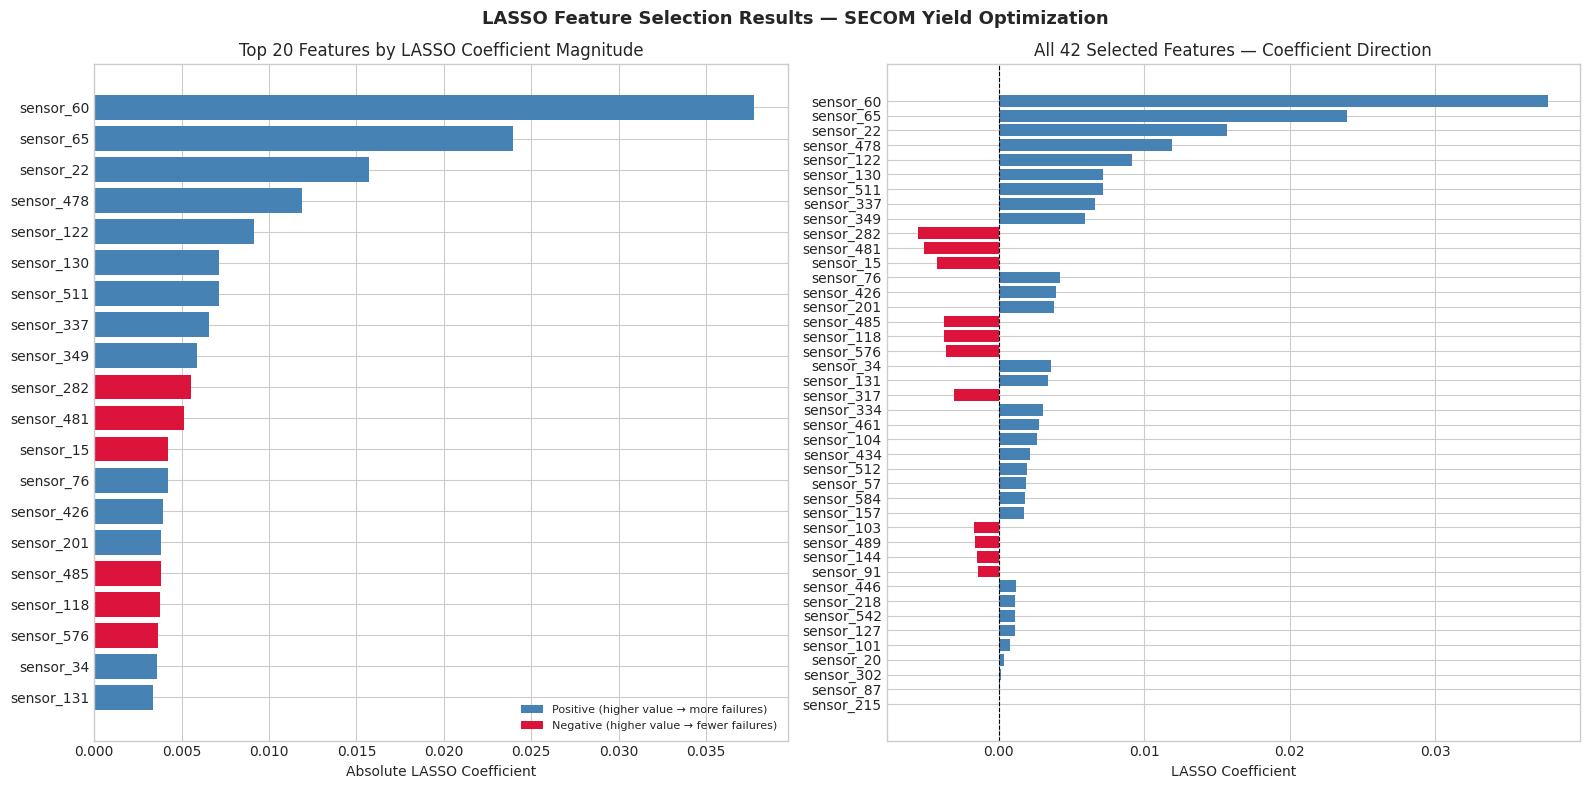

In [6]:
#Visualize LASSO feature rankings
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# plot top 20 features by absolute coefficient
top20 = selected_features.head(20)
colors = ['crimson' if c < 0 else 'steelblue' for c in top20['coefficient']]

axes[0].barh(top20['sensor'], top20['abs_coefficient'], color=colors)
axes[0].set_xlabel('Absolute LASSO Coefficient')
axes[0].set_title('Top 20 Features by LASSO Coefficient Magnitude')
axes[0].invert_yaxis()  # highest coefficient at top

# Add a legend explaining colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='Positive (higher value → more failures)'),
    Patch(facecolor='crimson', label='Negative (higher value → fewer failures)')
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=8)

# plot all 42 selected features showing positive vs negative coefficients
colors_all = ['crimson' if c < 0 else 'steelblue' for c in selected_features['coefficient']]
axes[1].barh(selected_features['sensor'], selected_features['coefficient'], color=colors_all)
axes[1].set_xlabel('LASSO Coefficient')
axes[1].set_title('All 42 Selected Features — Coefficient Direction')
axes[1].invert_yaxis()
axes[1].axvline(x=0, color='black', linewidth=0.8, linestyle='--')

plt.suptitle('LASSO Feature Selection Results — SECOM Yield Optimization',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/jupyter/secom-yield-optimization/data/processed/lasso_feature_ranking.png',
            dpi=150, bbox_inches='tight')
plt.show()


In [7]:
from scipy.stats import mannwhitneyu

# For each of the 42 LASSO-selected features, test whether
# the distribution of that sensor is significantly different
# between passing and failing wafers
pass_df = df[df['label'] == 0]   # 1463 passing wafers
fail_df = df[df['label'] == 1]   # 104 failing wafers

selected_sensor_names = selected_features['sensor'].tolist()

significance_results = []

for sensor in selected_sensor_names:
    pass_vals = pass_df[sensor].values
    fail_vals = fail_df[sensor].values
    
    # Mann-Whitney U test — non-parametric test comparing two distributions
    # Does not assume normal distribution — appropriate for sensor data
    # H0 (null hypothesis): the two distributions are identical
    # If p < 0.05 we reject H0 — the sensor behaves differently for pass vs fail
    stat, p_value = mannwhitneyu(pass_vals, fail_vals, alternative='two-sided')
    
    significance_results.append({
        'sensor': sensor,
        'coefficient': selected_features[selected_features['sensor'] == sensor]['coefficient'].values[0],
        'abs_coefficient': selected_features[selected_features['sensor'] == sensor]['abs_coefficient'].values[0],
        'mann_whitney_p': p_value,
        'significant': p_value < 0.05
    })

sig_df = pd.DataFrame(significance_results).sort_values('abs_coefficient', ascending=False)

print(f"Statistical significance of LASSO-selected features:")
print(f"Significant (p < 0.05): {sig_df['significant'].sum()} / {len(sig_df)}")
print(f"\nFull results:")
print(sig_df.to_string(index=False))

Statistical significance of LASSO-selected features:
Significant (p < 0.05): 24 / 42

Full results:
    sensor  coefficient  abs_coefficient  mann_whitney_p  significant
 sensor_60       0.0378           0.0378          0.0000         True
 sensor_65       0.0240           0.0240          0.1733        False
 sensor_22       0.0157           0.0157          0.0006         True
sensor_478       0.0119           0.0119          0.0000         True
sensor_122       0.0092           0.0092          0.0030         True
sensor_130       0.0072           0.0072          0.0000         True
sensor_511       0.0071           0.0071          0.0000         True
sensor_337       0.0066           0.0066          0.0050         True
sensor_349       0.0059           0.0059          0.0018         True
sensor_282      -0.0055           0.0055          0.0378         True
sensor_481      -0.0052           0.0052          0.5978        False
 sensor_15      -0.0042           0.0042          0.0133    

In [8]:
# keep features that pass EITHER criterion
# Tier 1: significant by BOTH LASSO coefficient AND Mann-Whitney (high confidence)
# Tier 2: strong LASSO coefficient but not significant (predictive but not individually separating)
# Tier 3: significant by Mann-Whitney but weak LASSO coefficient

# Define tiers
tier1 = sig_df[sig_df['significant'] & (sig_df['abs_coefficient'] >= 0.003)]
tier2 = sig_df[~sig_df['significant'] & (sig_df['abs_coefficient'] >= 0.005)]
tier3 = sig_df[sig_df['significant'] & (sig_df['abs_coefficient'] < 0.003)]

print(f"Tier 1 — Strong LASSO + Significant (high confidence): {len(tier1)} features")
print(tier1['sensor'].tolist())

print(f"\nTier 2 — Strong LASSO but not significant (predictive): {len(tier2)} features")
print(tier2['sensor'].tolist())

print(f"\nTier 3 — Significant but weak LASSO (statistical only): {len(tier3)} features")
print(tier3['sensor'].tolist())

# Final feature set: Tier 1 + Tier 2
# We prioritize predictive power for the yield model
final_features = pd.concat([tier1, tier2]).sort_values('abs_coefficient', ascending=False)
final_feature_names = final_features['sensor'].tolist()

print(f"\nFinal feature set: {len(final_feature_names)} features")
print(f"Features: {final_feature_names}")

Tier 1 — Strong LASSO + Significant (high confidence): 16 features
['sensor_60', 'sensor_22', 'sensor_478', 'sensor_122', 'sensor_130', 'sensor_511', 'sensor_337', 'sensor_349', 'sensor_282', 'sensor_15', 'sensor_426', 'sensor_201', 'sensor_34', 'sensor_131', 'sensor_317', 'sensor_334']

Tier 2 — Strong LASSO but not significant (predictive): 2 features
['sensor_65', 'sensor_481']

Tier 3 — Significant but weak LASSO (statistical only): 8 features
['sensor_461', 'sensor_104', 'sensor_512', 'sensor_57', 'sensor_103', 'sensor_91', 'sensor_127', 'sensor_101']

Final feature set: 18 features
Features: ['sensor_60', 'sensor_65', 'sensor_22', 'sensor_478', 'sensor_122', 'sensor_130', 'sensor_511', 'sensor_337', 'sensor_349', 'sensor_282', 'sensor_481', 'sensor_15', 'sensor_426', 'sensor_201', 'sensor_34', 'sensor_131', 'sensor_317', 'sensor_334']


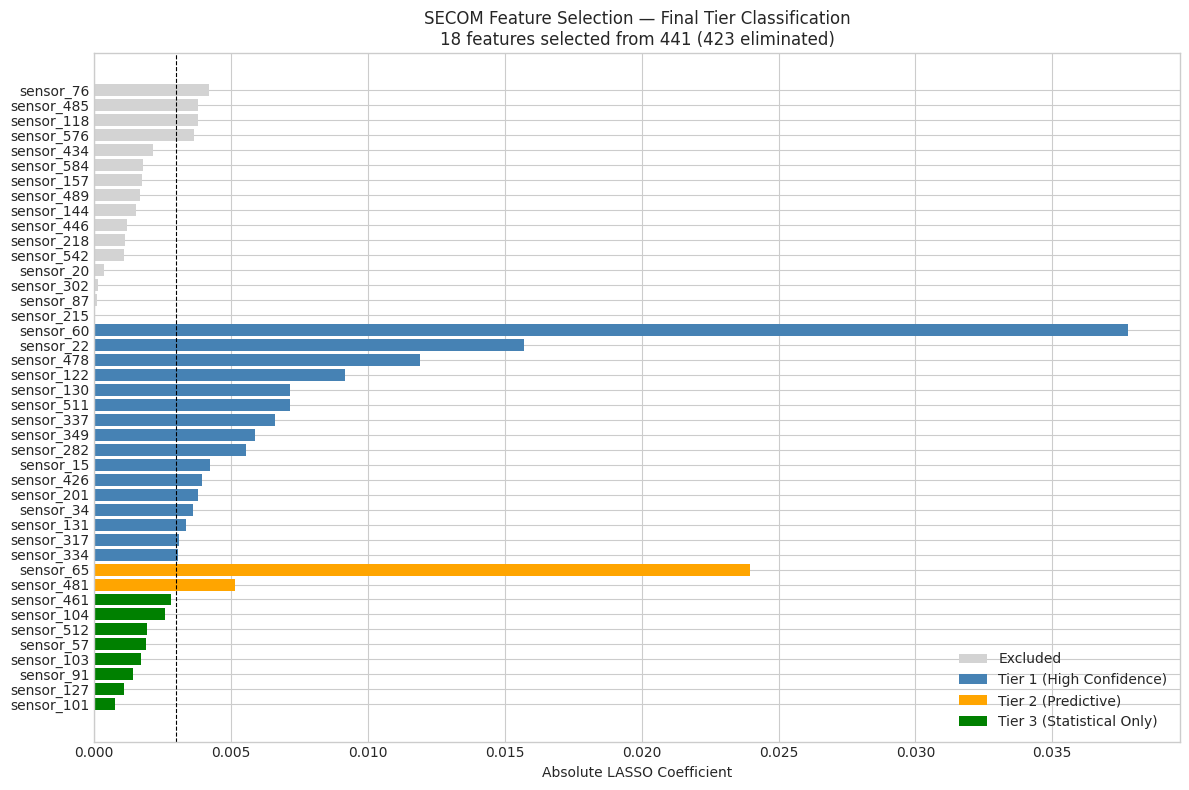

In [9]:
fig, ax = plt.subplots(figsize=(12, 8))

# Add tier column to sig_df for visualization
sig_df['tier'] = 'Excluded'
sig_df.loc[sig_df['sensor'].isin(tier1['sensor']), 'tier'] = 'Tier 1 (High Confidence)'
sig_df.loc[sig_df['sensor'].isin(tier2['sensor']), 'tier'] = 'Tier 2 (Predictive)'
sig_df.loc[sig_df['sensor'].isin(tier3['sensor']), 'tier'] = 'Tier 3 (Statistical Only)'

# Color map for tiers
color_map = {
    'Tier 1 (High Confidence)': 'steelblue',
    'Tier 2 (Predictive)':      'orange',
    'Tier 3 (Statistical Only)':'green',
    'Excluded':                  'lightgrey'
}

# Plot all 42 LASSO features colored by tier
for tier, group in sig_df.groupby('tier'):
    ax.barh(
        group['sensor'],
        group['abs_coefficient'],
        color=color_map[tier],
        label=tier
    )

ax.set_xlabel('Absolute LASSO Coefficient')
ax.set_title('SECOM Feature Selection — Final Tier Classification\n'
             f'18 features selected from 441 ({441-18} eliminated)')
ax.invert_yaxis()
ax.legend(loc='lower right')
ax.axvline(x=0.003, color='black', linestyle='--', linewidth=0.8, label='Tier threshold (0.003)')

plt.tight_layout()
plt.savefig('/home/jupyter/secom-yield-optimization/data/processed/feature_tiers.png',
            dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# Save the tiered feature summary
sig_df.to_csv(
    '/home/jupyter/secom-yield-optimization/data/processed/feature_selection_results.csv',
    index=False
)

# Save the selected feature dataset for use in Notebook 3
# Include only final 18 features + label + timestamp
df_selected = df[final_feature_names + ['label', 'timestamp']].copy()
df_selected.to_csv(
    '/home/jupyter/secom-yield-optimization/data/processed/secom_selected_features.csv',
    index=False
)

print(f"Feature selection results saved")
print(f"Selected feature dataset saved ")
print(f"\nSelected dataset shape: {df_selected.shape}")
print(f"\nClass distribution in selected dataset:")
print(df_selected['label'].value_counts())

# Upload to GCS
import subprocess
files = [
    'data/processed/feature_selection_results.csv',
    'data/processed/secom_selected_features.csv',
    'data/processed/lasso_feature_ranking.png',
    'data/processed/feature_tiers.png'
]

base = '/home/jupyter/secom-yield-optimization/'
bucket = 'gs://secom-data-temi/'

for f in files:
    result = subprocess.run(
        ['gsutil', 'cp', base + f, bucket + f],
        capture_output=True, text=True
    )
    status = "Success!" if result.returncode == 0 else "Failed!"
    print(f"{status} {f}")

Feature selection results saved
Selected feature dataset saved 

Selected dataset shape: (1567, 20)

Class distribution in selected dataset:
label
0    1463
1     104
Name: count, dtype: int64
Success! data/processed/feature_selection_results.csv
Success! data/processed/secom_selected_features.csv
Success! data/processed/lasso_feature_ranking.png
Success! data/processed/feature_tiers.png
